# PeopleFirst HR Consulting — Workforce Attrition EDA
## Analyst: Vijay Mohan | Python (Pandas · NumPy · Matplotlib · Seaborn)
---
**Objective:** Visually investigate the 20.3% attrition rate at PeopleFirst HR Consulting
through exploratory data analysis. Each chart answers a specific stakeholder question raised
in the January 2026 CHRO board review.

**Dataset:** `peoplefirst_hr_2025.csv` — 1,200 employee records, 21 features

**What this notebook covers:**
1. Data loading, inspection & cleaning
2. Attrition overview — scale of the problem
3. Department-wise attrition analysis
4. Demographic analysis — age, gender, marital status
5. Salary & satisfaction analysis
6. Tenure & experience analysis
7. Workload analysis — overtime & travel
8. Correlation heatmap — what drives attrition most?
9. Attrition risk profile — who is most likely to leave next?
10. Key findings summary


## 1. Setup — Import Libraries & Load Data

In [14]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ────────────────────────────────────────────────
plt.rcParams['figure.dpi']       = 120
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False
plt.rcParams['axes.titlesize']   = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize']   = 11

# ── Colour palette ────────────────────────────────────────────
BLUE    = '#2E75B6'
ORANGE  = '#ED7D31'
RED     = '#C00000'
GREEN   = '#70AD47'
PURPLE  = '#7030A0'
GRAY    = '#BFBFBF'
PALETTE = [BLUE, ORANGE, GREEN, PURPLE, RED]

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [15]:

# Load the dataset
df = pd.read_csv('peoplefirst_hr_2025.csv')

print(f"Shape         : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names  :")
for col in df.columns:
    print(f"  {col:35s} {df[col].dtype}")


Shape         : 1200 rows × 21 columns

Column names  :
  employee_id                         str
  age                                 int64
  gender                              str
  marital_status                      str
  department                          str
  job_role                            str
  education_level                     str
  years_at_company                    int64
  years_in_role                       int64
  monthly_salary                      int64
  salary_hike_pct                     int64
  job_satisfaction                    int64
  work_life_balance                   int64
  environment_satisfaction            int64
  overtime                            str
  business_travel                     str
  num_companies_worked                int64
  distance_from_home_km               int64
  performance_rating                  int64
  training_hours_last_year            int64
  attrition                           str


In [16]:

# Quick inspection
print("=== First 5 rows ===")
display(df.head())

print("\n=== Missing values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values — clean dataset ✓")

print("\n=== Attrition distribution ===")
att_counts = df['attrition'].value_counts()
att_pct    = df['attrition'].value_counts(normalize=True) * 100
for k in att_counts.index:
    print(f"  {k:5s}  {att_counts[k]:4d} employees  ({att_pct[k]:.1f}%)")


=== First 5 rows ===


,employee_id,age,gender,marital_status,department,job_role,education_level,years_at_company,years_in_role,monthly_salary,...,job_satisfaction,work_life_balance,environment_satisfaction,overtime,business_travel,num_companies_worked,distance_from_home_km,performance_rating,training_hours_last_year,attrition
0,EMP0001,33,Female,Single,Sales,Account Manager,Post-Graduate,8,5,100276,...,3,3,4,No,Rarely,3,51,4,47,No
1,EMP0002,31,Female,Married,Operations,Process Associate,Post-Graduate,10,0,91013,...,3,4,3,No,No Travel,0,28,3,68,No
2,EMP0003,51,Male,Married,Finance,Accounts Executive,Graduate,5,5,101723,...,3,4,4,No,No Travel,0,11,3,53,No
3,EMP0004,31,Male,Married,Sales,Sales Executive,Graduate,4,4,82640,...,4,4,3,No,Rarely,2,23,4,60,No
4,EMP0005,31,Male,Divorced,Technology,Tech Lead,Graduate,3,1,116099,...,4,3,4,No,Rarely,7,52,3,32,Yes



=== Missing values ===
No missing values — clean dataset ✓

=== Attrition distribution ===
  No      956 employees  (79.7%)
  Yes     244 employees  (20.3%)


## 2. Data Preparation

In [17]:

# Create helper columns used throughout the notebook

# Binary attrition flag (1 = left, 0 = stayed)
df['attrition_flag'] = (df['attrition'] == 'Yes').astype(int)

# Age bands
df['age_band'] = pd.cut(df['age'],
    bins=[21, 25, 30, 35, 40, 50, 60],
    labels=['22–25','26–30','31–35','36–40','41–50','51+'])

# Tenure bands
df['tenure_band'] = pd.cut(df['years_at_company'],
    bins=[-1, 1, 2, 4, 7, 10, 20],
    labels=['0–1 yr','1–2 yrs','3–4 yrs','5–7 yrs','8–10 yrs','10+ yrs'])

# Salary hike bands
df['hike_band'] = pd.cut(df['salary_hike_pct'],
    bins=[0, 7, 12, 18, 30],
    labels=['Below 8%','8–12%','13–18%','19%+'])

# Satisfaction labels
sat_map = {1:'Low', 2:'Medium', 3:'High', 4:'Very High'}
df['job_sat_label']  = df['job_satisfaction'].map(sat_map)
df['wlb_label']      = df['work_life_balance'].map(sat_map)
df['env_sat_label']  = df['environment_satisfaction'].map(sat_map)

# Risk score (same logic as SQL)
risk_cols = [
    (df['overtime']              == 'Yes'),
    (df['job_satisfaction']      <= 2),
    (df['work_life_balance']     <= 2),
    (df['years_at_company']      <= 2),
    (df['business_travel']       == 'Frequently'),
    (df['salary_hike_pct']       < 8),
    (df['age']                   < 30),
    (df['environment_satisfaction'] <= 2)
]
df['risk_score'] = sum(c.astype(int) for c in risk_cols)
df['risk_level'] = pd.cut(df['risk_score'],
    bins=[-1, 2, 4, 8],
    labels=['Low Risk','Medium Risk','High Risk'])

print("Data preparation complete.")
print(f"New columns added: age_band, tenure_band, hike_band, job_sat_label,")
print(f"                   wlb_label, env_sat_label, risk_score, risk_level")
display(df[['age_band','tenure_band','hike_band','risk_score','risk_level']].head(3))


Data preparation complete.
New columns added: age_band, tenure_band, hike_band, job_sat_label,
                   wlb_label, env_sat_label, risk_score, risk_level


,age_band,tenure_band,hike_band,risk_score,risk_level
0,31–35,8–10 yrs,19%+,0,Low Risk
1,31–35,8–10 yrs,19%+,0,Low Risk
2,51+,5–7 yrs,13–18%,0,Low Risk


## 3. Attrition Overview
**Stakeholder question:** *"What is our actual attrition rate vs industry benchmark?"*

**Why this chart:** A donut chart immediately communicates the split — 20.3% left vs 79.7%
stayed. The benchmark annotation shows at a glance how far above normal PeopleFirst is.
The bar below adds the financial cost context that the Finance Head needs.


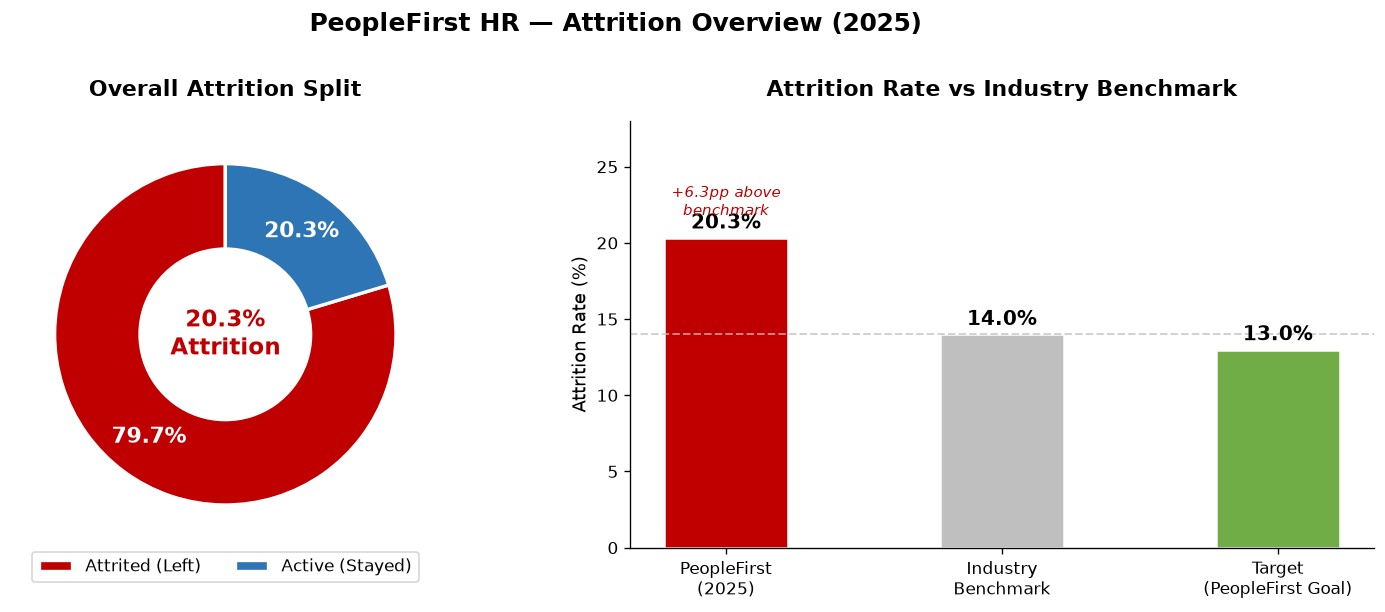


📌 Key stat: Attrition = 20.3% | Industry = 14% | Gap = 6.3 percentage points
📌 Financial cost: 244 employees × ₹4L = ₹9.76 Cr replacement cost


In [18]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('PeopleFirst HR — Attrition Overview (2025)', fontsize=15, fontweight='bold', y=1.01)

# ── Left: Donut chart ─────────────────────────────────────────
ax1 = axes[0]
sizes  = df['attrition'].value_counts()
colors = [RED, BLUE]
wedges, texts, autotexts = ax1.pie(
    sizes, labels=None, autopct='%1.1f%%',
    colors=colors, startangle=90,
    pctdistance=0.75, wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2))
for t in autotexts:
    t.set_fontsize(13); t.set_fontweight('bold'); t.set_color('white')
ax1.legend(['Attrited (Left)', 'Active (Stayed)'],
           loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=10)
ax1.set_title('Overall Attrition Split', pad=15)
ax1.text(0, 0, f"{df['attrition_flag'].mean()*100:.1f}%\nAttrition",
         ha='center', va='center', fontsize=14, fontweight='bold', color=RED)

# ── Right: Benchmark comparison bar ──────────────────────────
ax2 = axes[1]
categories   = ['PeopleFirst\n(2025)', 'Industry\nBenchmark', 'Target\n(PeopleFirst Goal)']
values       = [df['attrition_flag'].mean()*100, 14.0, 13.0]
bar_colors   = [RED, GRAY, GREEN]
bars = ax2.bar(categories, values, color=bar_colors, width=0.45, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.axhline(14.0, color=GRAY, linestyle='--', linewidth=1.2, alpha=0.7)
ax2.set_ylabel('Attrition Rate (%)', fontsize=11)
ax2.set_title('Attrition Rate vs Industry Benchmark', pad=15)
ax2.set_ylim(0, 28)
ax2.text(0, df['attrition_flag'].mean()*100 + 1.5,
         f"+{df['attrition_flag'].mean()*100 - 14:.1f}pp above\nbenchmark",
         ha='center', fontsize=9, color=RED, style='italic')

plt.tight_layout()
plt.savefig('plot_01_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"\n📌 Key stat: Attrition = {df['attrition_flag'].mean()*100:.1f}% | Industry = 14% | Gap = {df['attrition_flag'].mean()*100 - 14:.1f} percentage points")
print(f"📌 Financial cost: {df['attrition_flag'].sum()} employees × ₹4L = ₹{df['attrition_flag'].sum()*4/100:.2f} Cr replacement cost")


## 4. Department-wise Attrition
**Stakeholder question:** *"Which department is bleeding the most talent?"*

**Why these charts:** The horizontal bar chart ranks departments by attrition rate — immediate
visual answer. The grouped bar below adds headcount context so you can see whether a high rate
in a small department is more or less alarming than a moderate rate in a large one.


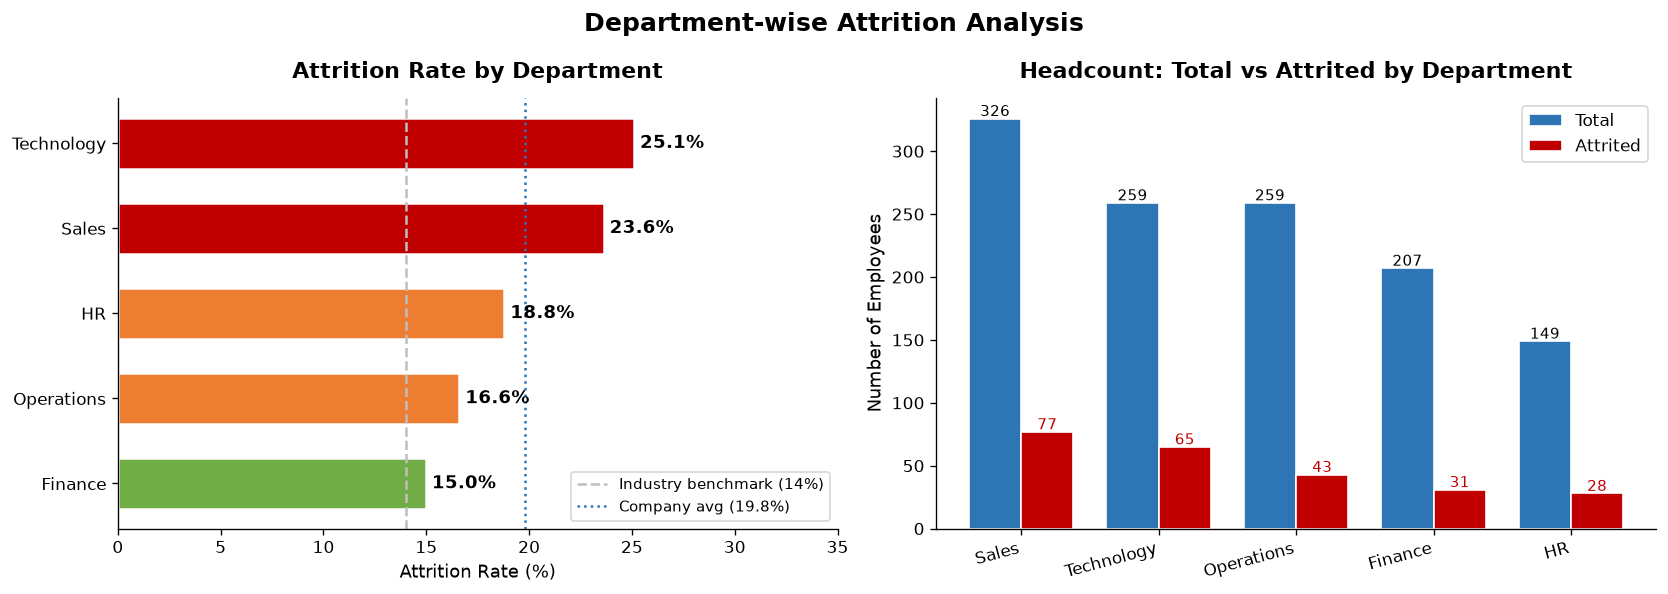

,department,total,attrited,attrition_%,avg_monthly_salary
0,Technology,259,65,25.096525,146107.077220
1,Sales,326,77,23.619632,98845.024540
2,HR,149,28,18.791946,81410.966443
3,Operations,259,43,16.602317,73013.220077
4,Finance,207,31,14.975845,105628.135266


In [19]:

dept_stats = df.groupby('department').agg(
    total    = ('employee_id', 'count'),
    attrited = ('attrition_flag', 'sum'),
    avg_sal  = ('monthly_salary', 'mean')
).reset_index()
dept_stats['rate'] = dept_stats['attrited'] / dept_stats['total'] * 100
dept_stats = dept_stats.sort_values('rate', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Department-wise Attrition Analysis', fontsize=15, fontweight='bold')

# ── Left: Attrition rate by dept ─────────────────────────────
ax1 = axes[0]
bar_colors = [RED if r > 20 else ORANGE if r > 15 else GREEN
              for r in dept_stats['rate']]
bars = ax1.barh(dept_stats['department'], dept_stats['rate'],
                color=bar_colors, edgecolor='white', linewidth=1.5, height=0.6)
ax1.axvline(14, color=GRAY, linestyle='--', linewidth=1.5, label='Industry benchmark (14%)')
ax1.axvline(dept_stats['rate'].mean(), color=BLUE, linestyle=':', linewidth=1.5,
            label=f"Company avg ({dept_stats['rate'].mean():.1f}%)")
for bar, val in zip(bars, dept_stats['rate']):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
ax1.set_xlabel('Attrition Rate (%)')
ax1.set_title('Attrition Rate by Department', pad=12)
ax1.legend(fontsize=9)
ax1.set_xlim(0, 35)

# ── Right: Headcount breakdown ────────────────────────────────
ax2 = axes[1]
dept_sorted = dept_stats.sort_values('total', ascending=False)
x = np.arange(len(dept_sorted))
w = 0.38
b1 = ax2.bar(x - w/2, dept_sorted['total'],    w, label='Total',    color=BLUE,   edgecolor='white')
b2 = ax2.bar(x + w/2, dept_sorted['attrited'], w, label='Attrited', color=RED,    edgecolor='white')
ax2.set_xticks(x); ax2.set_xticklabels(dept_sorted['department'], rotation=15, ha='right')
ax2.set_ylabel('Number of Employees')
ax2.set_title('Headcount: Total vs Attrited by Department', pad=12)
ax2.legend()
for bar in b1:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(int(bar.get_height())), ha='center', fontsize=9)
for bar in b2:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(int(bar.get_height())), ha='center', fontsize=9, color=RED)

plt.tight_layout()
plt.savefig('plot_02_department.png', bbox_inches='tight', dpi=150)
plt.show()
display(dept_stats[['department','total','attrited','rate','avg_sal']]
        .rename(columns={'rate':'attrition_%','avg_sal':'avg_monthly_salary'})
        .sort_values('attrition_%', ascending=False)
        .reset_index(drop=True))


## 5. Demographic Analysis — Age, Gender & Marital Status
**Stakeholder question:** *"Is attrition higher among a particular age group or gender?"*

**Why these charts:** Three subplots in a row show the demographic story in one glance.
The age band bar immediately reveals the danger zone. Gender comparison checks for disparity.
Marital status tests the single-vs-married hypothesis.


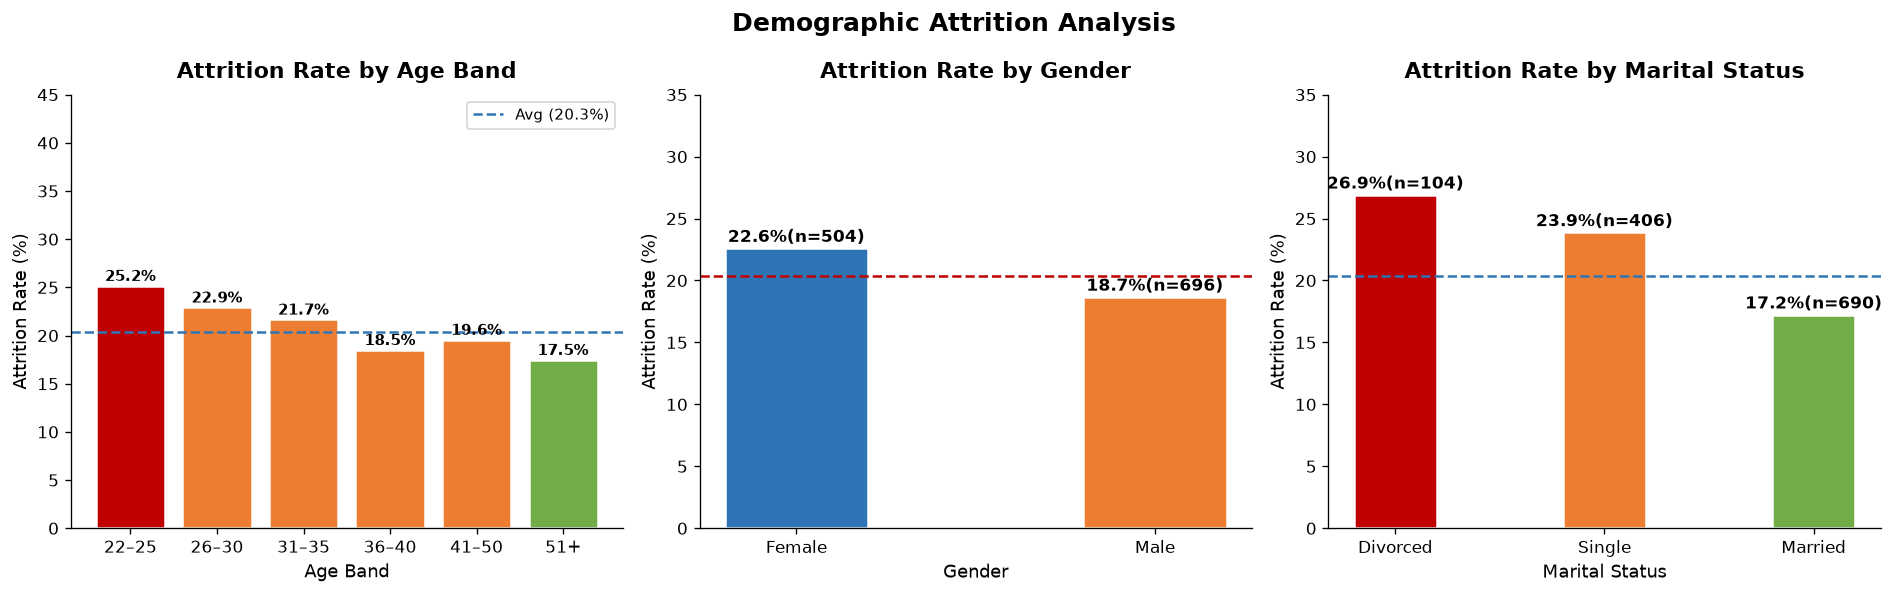

In [20]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Demographic Attrition Analysis', fontsize=15, fontweight='bold')

# ── Age band ──────────────────────────────────────────────────
ax1 = axes[0]
age_att = df.groupby('age_band', observed=True)['attrition_flag'].mean() * 100
colors_age = [RED if v > 25 else ORANGE if v > 18 else GREEN for v in age_att.values]
bars = ax1.bar(age_att.index, age_att.values, color=colors_age, edgecolor='white', linewidth=1.5)
ax1.axhline(df['attrition_flag'].mean()*100, color=BLUE, linestyle='--',
            linewidth=1.5, label=f"Avg ({df['attrition_flag'].mean()*100:.1f}%)")
for bar, val in zip(bars, age_att.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax1.set_xlabel('Age Band'); ax1.set_ylabel('Attrition Rate (%)')
ax1.set_title('Attrition Rate by Age Band', pad=10)
ax1.legend(fontsize=9); ax1.set_ylim(0, 45)

# ── Gender ────────────────────────────────────────────────────
ax2 = axes[1]
gen_att = df.groupby('gender').agg(
    rate  = ('attrition_flag', lambda x: x.mean()*100),
    count = ('attrition_flag', 'count'),
    avg_sal = ('monthly_salary', 'mean')
).reset_index()
bars2 = ax2.bar(gen_att['gender'], gen_att['rate'],
                color=[BLUE, ORANGE], edgecolor='white', linewidth=1.5, width=0.4)
ax2.axhline(df['attrition_flag'].mean()*100, color=RED, linestyle='--', linewidth=1.5)
for bar, row in zip(bars2, gen_att.itertuples()):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{row.rate:.1f}%(n={row.count})', ha='center', fontsize=10, fontweight='bold')
ax2.set_xlabel('Gender'); ax2.set_ylabel('Attrition Rate (%)')
ax2.set_title('Attrition Rate by Gender', pad=10); ax2.set_ylim(0, 35)

# ── Marital status ────────────────────────────────────────────
ax3 = axes[2]
mar_att = df.groupby('marital_status').agg(
    rate  = ('attrition_flag', lambda x: x.mean()*100),
    count = ('attrition_flag', 'count')
).reset_index().sort_values('rate', ascending=False)
colors_m = [RED if v > 25 else ORANGE if v > 18 else GREEN for v in mar_att['rate']]
bars3 = ax3.bar(mar_att['marital_status'], mar_att['rate'],
                color=colors_m, edgecolor='white', linewidth=1.5, width=0.4)
ax3.axhline(df['attrition_flag'].mean()*100, color=BLUE, linestyle='--', linewidth=1.5)
for bar, row in zip(bars3, mar_att.itertuples()):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{row.rate:.1f}%(n={row.count})', ha='center', fontsize=10, fontweight='bold')
ax3.set_xlabel('Marital Status'); ax3.set_ylabel('Attrition Rate (%)')
ax3.set_title('Attrition Rate by Marital Status', pad=10); ax3.set_ylim(0, 35)

plt.tight_layout()
plt.savefig('plot_03_demographics.png', bbox_inches='tight', dpi=150)
plt.show()


## 6. Salary & Job Satisfaction Analysis
**Stakeholder question:** *"Are employees leaving because of salary? How does pay compare to satisfaction?"*

**Why these charts:** Box plots show the full salary distribution for leavers vs stayers —
not just averages. This reveals whether leavers are concentrated at the low end of the pay scale.
The satisfaction bar chart directly maps low scores to high attrition.


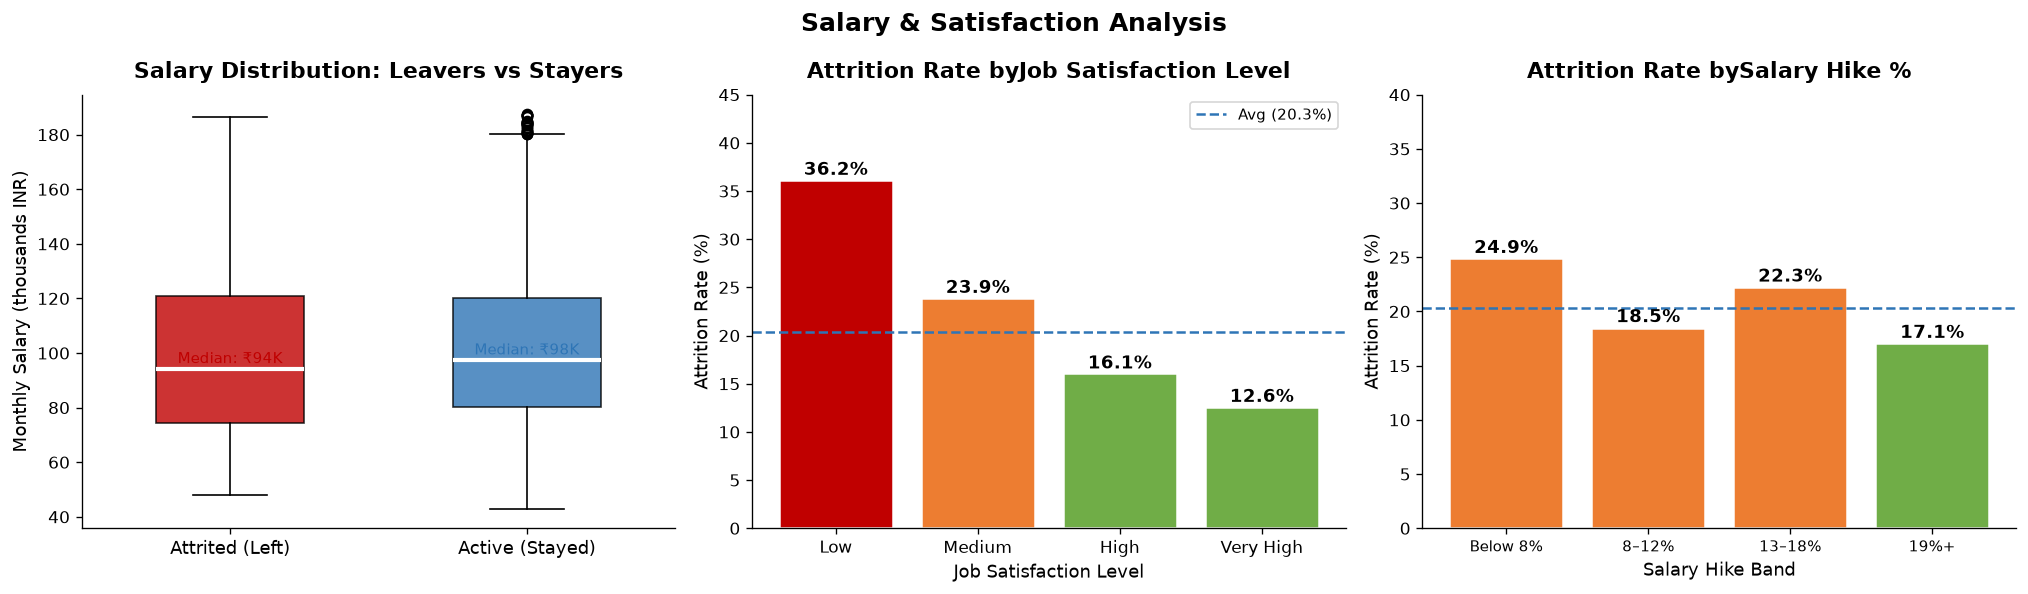

In [21]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Salary & Satisfaction Analysis', fontsize=15, fontweight='bold')

# ── Box plot: salary by attrition ────────────────────────────
ax1 = axes[0]
groups = [df[df['attrition']=='Yes']['monthly_salary'] / 1000,
          df[df['attrition']=='No']['monthly_salary']  / 1000]
bp = ax1.boxplot(groups, patch_artist=True, widths=0.5,
                 medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], [RED, BLUE]):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax1.set_xticklabels(['Attrited (Left)', 'Active (Stayed)'], fontsize=11)
ax1.set_ylabel('Monthly Salary (thousands INR)')
ax1.set_title('Salary Distribution: Leavers vs Stayers', pad=10)
med_left  = df[df['attrition']=='Yes']['monthly_salary'].median()/1000
med_stay  = df[df['attrition']=='No']['monthly_salary'].median()/1000
ax1.text(1, med_left+2, f'Median: ₹{med_left:.0f}K', ha='center', fontsize=9, color=RED)
ax1.text(2, med_stay+2, f'Median: ₹{med_stay:.0f}K', ha='center', fontsize=9, color=BLUE)

# ── Job satisfaction vs attrition ────────────────────────────
ax2 = axes[1]
sat_order = ['Low','Medium','High','Very High']
sat_att = df.groupby('job_sat_label', observed=False)['attrition_flag'].mean() * 100
sat_att = sat_att.reindex(sat_order)
colors_s = [RED, ORANGE, GREEN, GREEN]
bars = ax2.bar(sat_att.index, sat_att.values, color=colors_s, edgecolor='white', linewidth=1.5)
ax2.axhline(df['attrition_flag'].mean()*100, color=BLUE, linestyle='--',
            linewidth=1.5, label=f'Avg ({df["attrition_flag"].mean()*100:.1f}%)')
for bar, val in zip(bars, sat_att.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax2.set_xlabel('Job Satisfaction Level'); ax2.set_ylabel('Attrition Rate (%)')
ax2.set_title('Attrition Rate byJob Satisfaction Level', pad=10)
ax2.legend(fontsize=9); ax2.set_ylim(0, 45)

# ── Salary hike band vs attrition ────────────────────────────
ax3 = axes[2]
hike_att = df.groupby('hike_band', observed=True)['attrition_flag'].mean() * 100
colors_h = [RED if v > 25 else ORANGE if v > 18 else GREEN for v in hike_att.values]
bars3 = ax3.bar(hike_att.index, hike_att.values, color=colors_h, edgecolor='white', linewidth=1.5)
ax3.axhline(df['attrition_flag'].mean()*100, color=BLUE, linestyle='--', linewidth=1.5)
for bar, val in zip(bars3, hike_att.values):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax3.set_xlabel('Salary Hike Band'); ax3.set_ylabel('Attrition Rate (%)')
ax3.set_title('Attrition Rate bySalary Hike %', pad=10); ax3.set_ylim(0, 40)
ax3.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('plot_04_salary_satisfaction.png', bbox_inches='tight', dpi=150)
plt.show()


## 7. Tenure & Experience Analysis
**Stakeholder question:** *"Are we losing people in their first 2 years?"*

**Why this chart:** A line chart overlaid on bars shows both the count (how many employees
in each band) and the rate (what % are leaving). This combination prevents the misleading
impression that a high-count band with a moderate rate is more dangerous than a small-count
band with a very high rate.


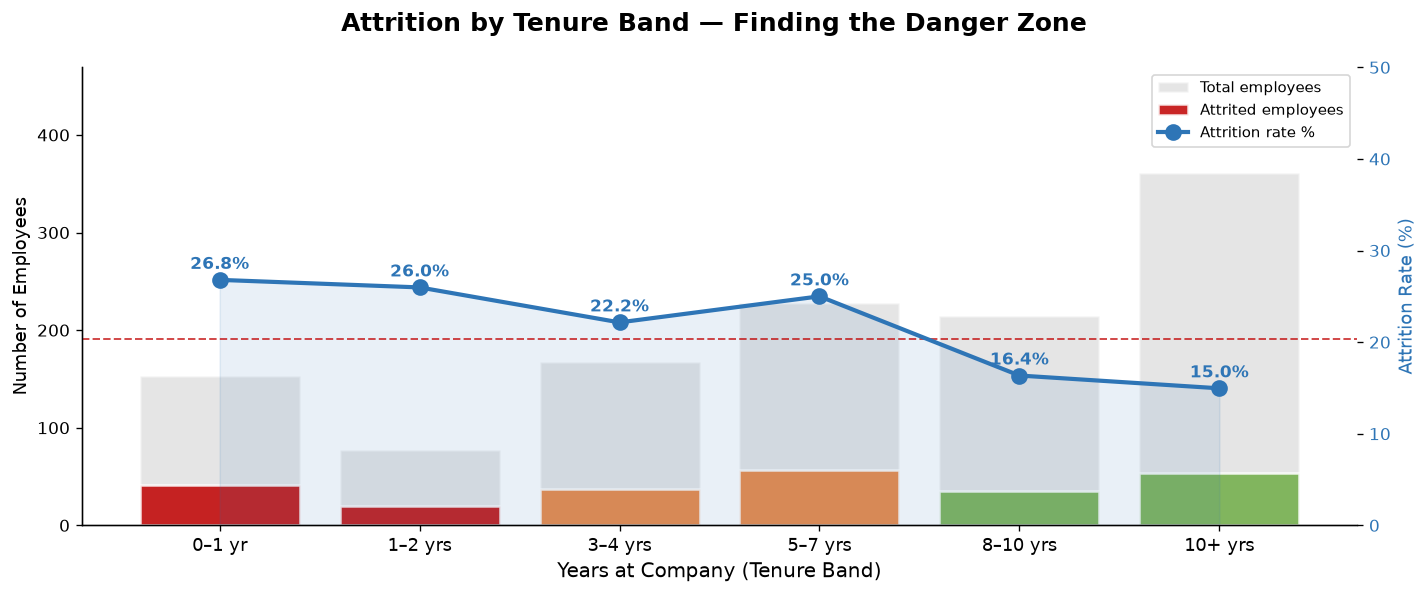


📌 Tenure Insights:
  0–1 yr       41/153  (26.8%) ← DANGER ZONE
  1–2 yrs      20/ 77  (26.0%) ← DANGER ZONE
  3–4 yrs      37/167  (22.2%)
  5–7 yrs      57/228  (25.0%)
  8–10 yrs     35/214  (16.4%)
  10+ yrs      54/361  (15.0%)


In [22]:

fig, ax1 = plt.subplots(figsize=(12, 5))
fig.suptitle('Attrition by Tenure Band — Finding the Danger Zone', fontsize=15, fontweight='bold')

tenure_stats = df.groupby('tenure_band', observed=True).agg(
    total    = ('attrition_flag','count'),
    attrited = ('attrition_flag','sum')
).reset_index()
tenure_stats['rate'] = tenure_stats['attrited'] / tenure_stats['total'] * 100

x = np.arange(len(tenure_stats))
colors_t = [RED if r > 25 else ORANGE if r > 18 else GREEN for r in tenure_stats['rate']]

bars = ax1.bar(x, tenure_stats['total'], color=GRAY, alpha=0.4,
               label='Total employees', edgecolor='white', linewidth=1.5)
ax1.bar(x, tenure_stats['attrited'], color=colors_t, alpha=0.85,
        label='Attrited employees', edgecolor='white', linewidth=1.5)

ax2 = ax1.twinx()
ax2.plot(x, tenure_stats['rate'], color=BLUE, marker='o', linewidth=2.5,
         markersize=9, label='Attrition rate %', zorder=5)
ax2.fill_between(x, tenure_stats['rate'], alpha=0.1, color=BLUE)
for i, (xi, val) in enumerate(zip(x, tenure_stats['rate'])):
    ax2.text(xi, val + 1.2, f'{val:.1f}%', ha='center', fontsize=10,
             fontweight='bold', color=BLUE)

ax1.set_xticks(x); ax1.set_xticklabels(tenure_stats['tenure_band'], fontsize=11)
ax1.set_xlabel('Years at Company (Tenure Band)', fontsize=12)
ax1.set_ylabel('Number of Employees', fontsize=11)
ax2.set_ylabel('Attrition Rate (%)', fontsize=11, color=BLUE)
ax2.tick_params(axis='y', labelcolor=BLUE)
ax2.axhline(df['attrition_flag'].mean()*100, color=RED, linestyle='--',
            linewidth=1.2, alpha=0.7)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right', fontsize=9)
ax1.set_ylim(0, tenure_stats['total'].max() * 1.3)
ax2.set_ylim(0, 50)

plt.tight_layout()
plt.savefig('plot_05_tenure.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n📌 Tenure Insights:")
for _, row in tenure_stats.iterrows():
    flag = " ← DANGER ZONE" if row['rate'] > 25 else ""
    print(f"  {str(row['tenure_band']):10s}  {row['attrited']:3.0f}/{row['total']:3.0f}  ({row['rate']:.1f}%){flag}")


## 8. Workload Analysis — Overtime & Business Travel
**Stakeholder question:** *"Do employees who travel frequently or work overtime leave more often?"*

**Why these charts:** Side-by-side comparisons for both overtime and travel clearly show
the workload-attrition relationship. The combined heatmap below adds the department layer
— showing which departments are suffering from high-overtime + high-attrition simultaneously.


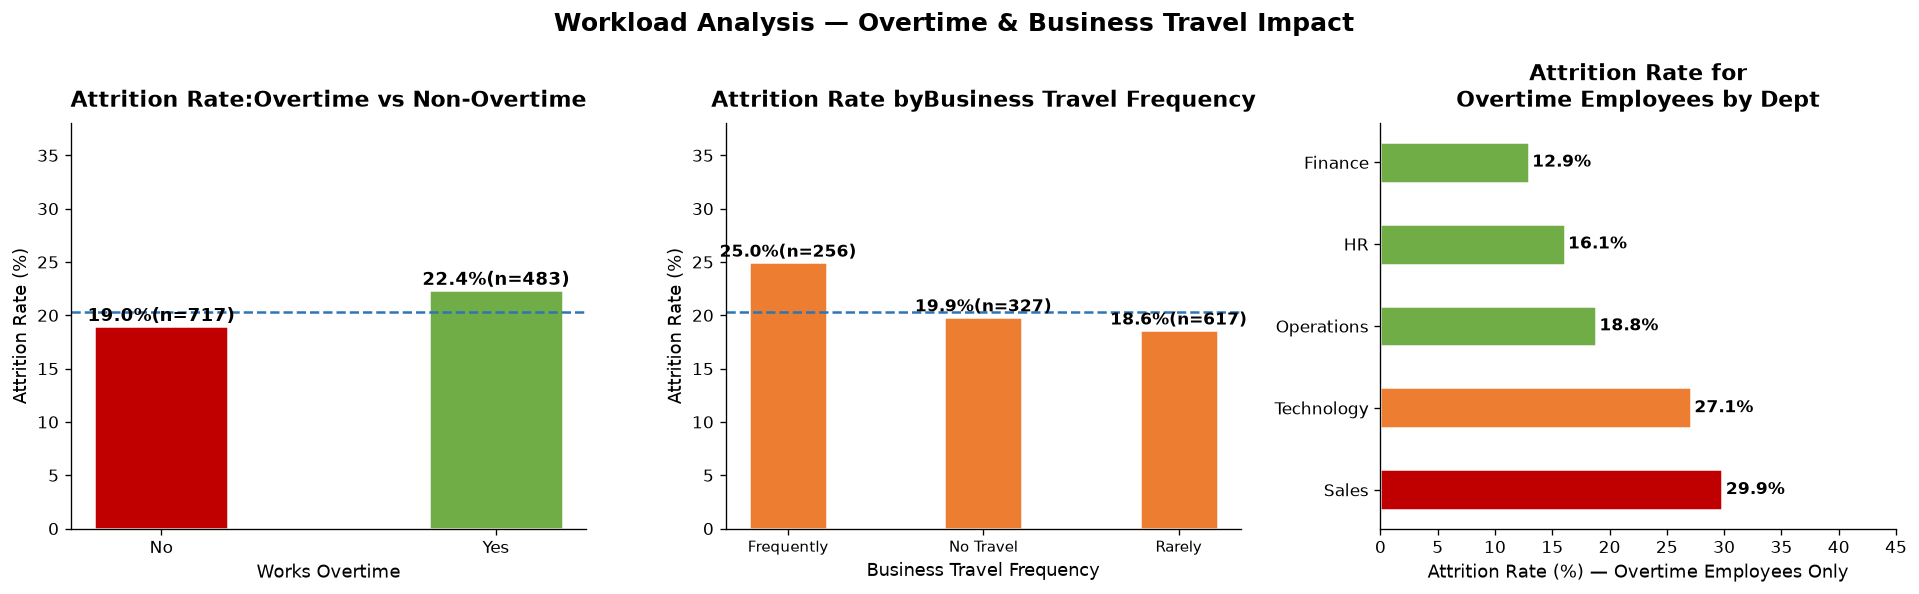

In [23]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Workload Analysis — Overtime & Business Travel Impact', fontsize=15, fontweight='bold')

# ── Overtime ──────────────────────────────────────────────────
ax1 = axes[0]
ot_stats = df.groupby('overtime').agg(
    total    = ('attrition_flag','count'),
    attrited = ('attrition_flag','sum'),
    avg_wlb  = ('work_life_balance','mean'),
    avg_sat  = ('job_satisfaction','mean')
).reset_index()
ot_stats['rate'] = ot_stats['attrited'] / ot_stats['total'] * 100
bars = ax1.bar(ot_stats['overtime'], ot_stats['rate'],
               color=[RED, GREEN], edgecolor='white', linewidth=1.5, width=0.4)
ax1.axhline(df['attrition_flag'].mean()*100, color=BLUE, linestyle='--', linewidth=1.5)
for bar, row in zip(bars, ot_stats.itertuples()):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{row.rate:.1f}%(n={row.total})', ha='center', fontsize=11, fontweight='bold')
ax1.set_xlabel('Works Overtime'); ax1.set_ylabel('Attrition Rate (%)')
ax1.set_title('Attrition Rate:Overtime vs Non-Overtime', pad=10); ax1.set_ylim(0, 38)

# ── Business travel ───────────────────────────────────────────
ax2 = axes[1]
tr_stats = df.groupby('business_travel').agg(
    total    = ('attrition_flag','count'),
    attrited = ('attrition_flag','sum')
).reset_index()
tr_stats['rate'] = tr_stats['attrited'] / tr_stats['total'] * 100
tr_stats = tr_stats.sort_values('rate', ascending=False)
colors_tr = [RED if r > 25 else ORANGE if r > 18 else GREEN for r in tr_stats['rate']]
bars2 = ax2.bar(tr_stats['business_travel'], tr_stats['rate'],
                color=colors_tr, edgecolor='white', linewidth=1.5, width=0.4)
ax2.axhline(df['attrition_flag'].mean()*100, color=BLUE, linestyle='--', linewidth=1.5)
for bar, row in zip(bars2, tr_stats.itertuples()):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{row.rate:.1f}%(n={row.total})', ha='center', fontsize=10, fontweight='bold')
ax2.set_xlabel('Business Travel Frequency'); ax2.set_ylabel('Attrition Rate (%)')
ax2.set_title('Attrition Rate byBusiness Travel Frequency', pad=10); ax2.set_ylim(0, 38)
ax2.tick_params(axis='x', labelsize=9)

# ── Overtime × Department heatmap ────────────────────────────
ax3 = axes[2]
ot_dept = df[df['overtime']=='Yes'].groupby('department')['attrition_flag'].mean() * 100
ot_dept = ot_dept.sort_values(ascending=False)
bars3 = ax3.barh(ot_dept.index, ot_dept.values,
                 color=[RED if v>28 else ORANGE if v>20 else GREEN for v in ot_dept.values],
                 edgecolor='white', linewidth=1.5, height=0.5)
for bar, val in zip(bars3, ot_dept.values):
    ax3.text(val+0.3, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax3.set_xlabel('Attrition Rate (%) — Overtime Employees Only')
ax3.set_title('Attrition Rate for\nOvertime Employees by Dept', pad=10)
ax3.set_xlim(0, 45)

plt.tight_layout()
plt.savefig('plot_06_workload.png', bbox_inches='tight', dpi=150)
plt.show()


## 9. Correlation Heatmap — What Drives Attrition Most?
**Why this chart:** A heatmap of correlations between all numeric features and attrition_flag
gives a single visual answer to "what matters most." Strong red/blue squares = strong
relationship. The top correlations bar chart below it ranks the drivers in order so the
CHRO knows exactly where to focus.


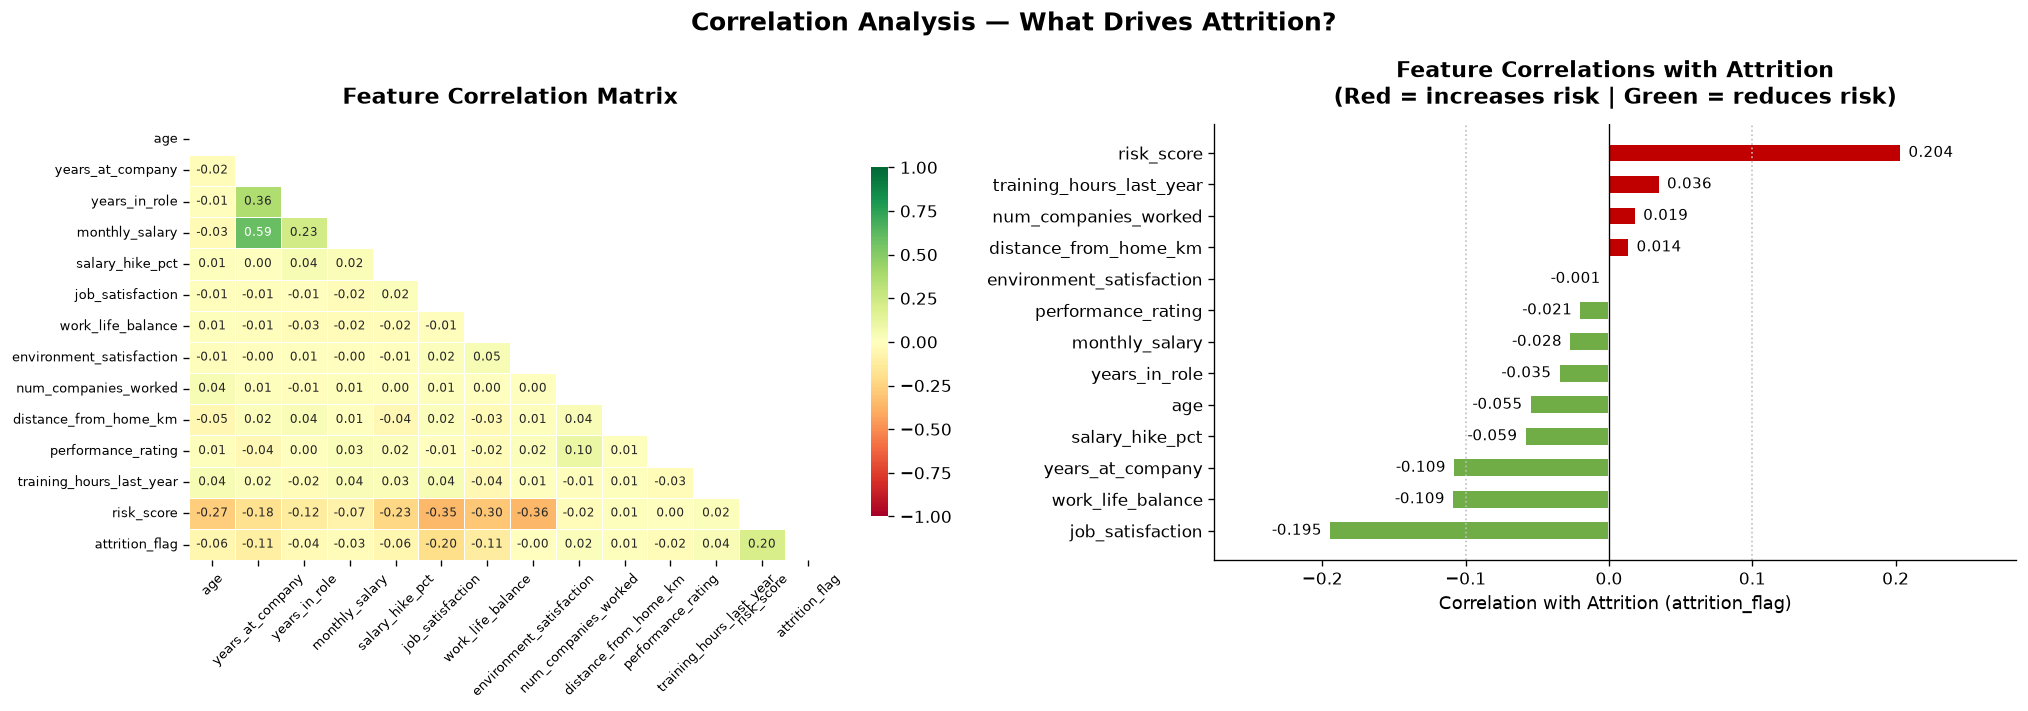


📌 Top 5 factors INCREASING attrition risk:
  risk_score                           r = +0.204
  training_hours_last_year             r = +0.036
  num_companies_worked                 r = +0.019
  distance_from_home_km                r = +0.014
  environment_satisfaction             r = -0.001

📌 Top 5 factors REDUCING attrition risk:
  job_satisfaction                     r = -0.195
  work_life_balance                    r = -0.109
  years_at_company                     r = -0.109
  salary_hike_pct                      r = -0.059
  age                                  r = -0.055


In [24]:

# Select numeric columns for correlation
num_cols = ['age','years_at_company','years_in_role','monthly_salary',
            'salary_hike_pct','job_satisfaction','work_life_balance',
            'environment_satisfaction','num_companies_worked',
            'distance_from_home_km','performance_rating',
            'training_hours_last_year','risk_score','attrition_flag']

corr_matrix = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Correlation Analysis — What Drives Attrition?', fontsize=15, fontweight='bold')

# ── Full heatmap ──────────────────────────────────────────────
ax1 = axes[0]
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax1, linewidths=0.5, annot_kws={'size':7},
            cbar_kws={'shrink':0.8})
ax1.set_title('Feature Correlation Matrix', pad=12)
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.tick_params(axis='y', rotation=0,  labelsize=8)

# ── Top correlations with attrition ──────────────────────────
ax2 = axes[1]
att_corr = corr_matrix['attrition_flag'].drop('attrition_flag').sort_values()
colors_c = [RED if v > 0 else GREEN for v in att_corr.values]
bars = ax2.barh(att_corr.index, att_corr.values, color=colors_c,
                edgecolor='white', linewidth=1.2, height=0.6)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.axvline(0.1,  color=GRAY, linestyle=':', linewidth=1)
ax2.axvline(-0.1, color=GRAY, linestyle=':', linewidth=1)
for bar, val in zip(bars, att_corr.values):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ha   = 'left' if val >= 0 else 'right'
    ax2.text(xpos, bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9, ha=ha)
ax2.set_xlabel('Correlation with Attrition (attrition_flag)')
ax2.set_title('Feature Correlations with Attrition\n(Red = increases risk | Green = reduces risk)', pad=12)
ax2.set_xlim(att_corr.min()-0.08, att_corr.max()+0.08)

plt.tight_layout()
plt.savefig('plot_07_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n📌 Top 5 factors INCREASING attrition risk:")
top_pos = att_corr.sort_values(ascending=False).head(5)
for feat, val in top_pos.items():
    print(f"  {feat:35s}  r = {val:+.3f}")
print("\n📌 Top 5 factors REDUCING attrition risk:")
top_neg = att_corr.sort_values().head(5)
for feat, val in top_neg.items():
    print(f"  {feat:35s}  r = {val:+.3f}")


## 10. Attrition Risk Profile — Who Is Most Likely to Leave Next?
**Stakeholder question (CEO):** *"Which employee profile is at highest risk of leaving next?"*

**Why this chart:** Risk score distribution for active employees shows how many people
are currently in the danger zone. The profile summary gives HR a concrete description of
the highest-risk employee archetype to guide proactive retention.


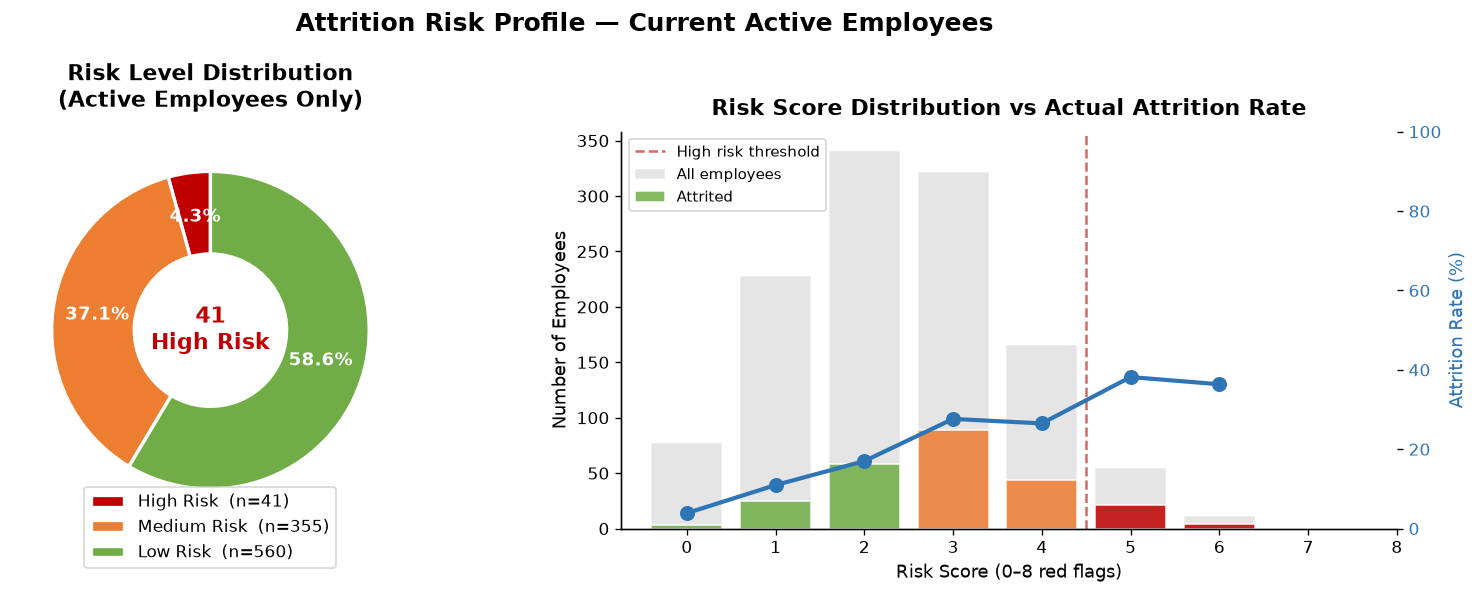


  HIGH-RISK EMPLOYEE PROFILE SUMMARY
  Total HIGH RISK employees   : 41
  Potential replacement cost  : ₹1.64 Cr
  Most common department      : Sales
  Most common age band        : 26–30
  % working overtime          : 80.5%
  Avg job satisfaction        : 2.07 / 4
  Avg work-life balance       : 2.54 / 4
  Avg years at company        : 4.6 yrs
  Avg monthly salary          : ₹88,975


In [25]:

active = df[df['attrition'] == 'No'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Attrition Risk Profile — Current Active Employees', fontsize=15, fontweight='bold')

# ── Risk level donut ──────────────────────────────────────────
ax1 = axes[0]
risk_counts = active['risk_level'].value_counts().reindex(['High Risk','Medium Risk','Low Risk'])
colors_r    = [RED, ORANGE, GREEN]
wedges, texts, autotexts = ax1.pie(
    risk_counts, labels=None, autopct='%1.1f%%',
    colors=colors_r, startangle=90,
    pctdistance=0.72, wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2))
for t in autotexts:
    t.set_fontsize(11); t.set_fontweight('bold'); t.set_color('white')
ax1.legend(
    [f'{lbl}  (n={cnt})' for lbl, cnt in risk_counts.items()],
    loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=1, fontsize=10)
ax1.set_title('Risk Level Distribution\n(Active Employees Only)', pad=15)
high_n   = risk_counts['High Risk']
high_cost = high_n * 4 / 100
ax1.text(0, 0, str(high_n) + '\nHigh Risk', ha='center', va='center',
         fontsize=13, fontweight='bold', color=RED)

# ── Risk score distribution ───────────────────────────────────
ax2 = axes[1]
score_att = df.groupby('risk_score').agg(
    total    = ('attrition_flag','count'),
    attrited = ('attrition_flag','sum')
).reset_index()
score_att['rate'] = score_att['attrited'] / score_att['total'] * 100

ax2.bar(score_att['risk_score'], score_att['total'], color=GRAY,
        alpha=0.4, label='All employees', edgecolor='white')
ax2.bar(score_att['risk_score'], score_att['attrited'],
        color=[RED if s>=5 else ORANGE if s>=3 else GREEN for s in score_att['risk_score']],
        alpha=0.85, label='Attrited', edgecolor='white')

ax2b = ax2.twinx()
ax2b.plot(score_att['risk_score'], score_att['rate'], color=BLUE,
          marker='o', linewidth=2.5, markersize=8, zorder=5)
ax2b.set_ylabel('Attrition Rate (%)', color=BLUE, fontsize=11)
ax2b.tick_params(axis='y', labelcolor=BLUE)
ax2b.set_ylim(0, 100)

ax2.axvline(4.5, color=RED, linestyle='--', linewidth=1.5, alpha=0.6, label='High risk threshold')
ax2.set_xlabel('Risk Score (0–8 red flags)', fontsize=11)
ax2.set_ylabel('Number of Employees', fontsize=11)
ax2.set_title('Risk Score Distribution vs Actual Attrition Rate', pad=10)
ax2.legend(loc='upper left', fontsize=9)
ax2.set_xticks(range(9))

plt.tight_layout()
plt.savefig('plot_08_risk_profile.png', bbox_inches='tight', dpi=150)
plt.show()

# High-risk profile summary
high_risk = active[active['risk_level'] == 'High Risk']
print(f"\n{'='*55}")
print(f"  HIGH-RISK EMPLOYEE PROFILE SUMMARY")
print(f"{'='*55}")
print(f"  Total HIGH RISK employees   : {len(high_risk)}")
print(f"  Potential replacement cost  : ₹{len(high_risk)*4/100:.2f} Cr")
print(f"  Most common department      : {high_risk['department'].mode()[0]}")
print(f"  Most common age band        : {high_risk['age_band'].mode()[0]}")
print(f"  % working overtime          : {(high_risk['overtime']=='Yes').mean()*100:.1f}%")
print(f"  Avg job satisfaction        : {high_risk['job_satisfaction'].mean():.2f} / 4")
print(f"  Avg work-life balance       : {high_risk['work_life_balance'].mean():.2f} / 4")
print(f"  Avg years at company        : {high_risk['years_at_company'].mean():.1f} yrs")
print(f"  Avg monthly salary          : ₹{high_risk['monthly_salary'].mean():,.0f}")
print(f"{'='*55}")


## 11. Hypothesis Validation Summary
At the start of this project we stated 8 hypotheses. Here we validate each one against the data.


In [26]:

tech_rate = df[df['department']=='Technology']['attrition_flag'].mean()*100
young_rate = df[df['age']<32]['attrition_flag'].mean()*100
old_rate   = df[df['age']>=32]['attrition_flag'].mean()*100
ot_rate    = df[df['overtime']=='Yes']['attrition_flag'].mean()*100
no_ot_rate = df[df['overtime']=='No']['attrition_flag'].mean()*100
low_sat    = df[df['job_satisfaction']<=2]['attrition_flag'].mean()*100
high_sat   = df[df['job_satisfaction']>=3]['attrition_flag'].mean()*100
early_ten  = df[df['years_at_company']<=2]['attrition_flag'].mean()*100
freq_trav  = df[df['business_travel']=='Frequently']['attrition_flag'].mean()*100
no_trav    = df[df['business_travel']=='No Travel']['attrition_flag'].mean()*100
low_hike   = df[df['salary_hike_pct']<8]['attrition_flag'].mean()*100
high_hike  = df[df['salary_hike_pct']>=18]['attrition_flag'].mean()*100
single_r   = df[df['marital_status']=='Single']['attrition_flag'].mean()*100
married_r  = df[df['marital_status']=='Married']['attrition_flag'].mean()*100

results = [
    ("H1", "Technology has highest attrition",
     tech_rate > df.groupby('department')['attrition_flag'].mean().drop('Technology').max()*100,
     f"Technology = {tech_rate:.1f}%"),
    ("H2", "Employees aged 25–32 leave more",
     young_rate > old_rate,
     f"Under 32: {young_rate:.1f}% | 32+: {old_rate:.1f}%"),
    ("H3", "Overtime = Yes → higher attrition",
     ot_rate > no_ot_rate,
     f"Overtime: {ot_rate:.1f}% | No OT: {no_ot_rate:.1f}%"),
    ("H4", "Low satisfaction → high attrition",
     low_sat > high_sat,
     f"Low sat: {low_sat:.1f}% | High sat: {high_sat:.1f}%"),
    ("H5", "0–2 year tenure = highest attrition",
     early_ten > df['attrition_flag'].mean()*100 * 1.2,
     f"0–2 yrs: {early_ten:.1f}% | Avg: {df['attrition_flag'].mean()*100:.1f}%"),
    ("H6", "Frequent travellers leave more",
     freq_trav > no_trav,
     f"Frequent: {freq_trav:.1f}% | No travel: {no_trav:.1f}%"),
    ("H7", "Low hike → higher attrition",
     low_hike > high_hike,
     f"Low hike: {low_hike:.1f}% | High hike: {high_hike:.1f}%"),
    ("H8", "Single employees leave more",
     single_r > married_r,
     f"Single: {single_r:.1f}% | Married: {married_r:.1f}%"),
]

print(f"\n{'='*65}")
print(f"  HYPOTHESIS VALIDATION RESULTS")
print(f"{'='*65}")
for hyp, text, result, evidence in results:
    status = "✅ CONFIRMED" if result else "❌ REJECTED"
    print(f"  {hyp}  {status}  |  {text}")
    print(f"         Evidence: {evidence}")
    print()



  HYPOTHESIS VALIDATION RESULTS
  H1  ✅ CONFIRMED  |  Technology has highest attrition
         Evidence: Technology = 25.1%

  H2  ✅ CONFIRMED  |  Employees aged 25–32 leave more
         Evidence: Under 32: 23.6% | 32+: 19.1%

  H3  ✅ CONFIRMED  |  Overtime = Yes → higher attrition
         Evidence: Overtime: 22.4% | No OT: 19.0%

  H4  ✅ CONFIRMED  |  Low satisfaction → high attrition
         Evidence: Low sat: 29.0% | High sat: 14.6%

  H5  ✅ CONFIRMED  |  0–2 year tenure = highest attrition
         Evidence: 0–2 yrs: 26.5% | Avg: 20.3%

  H6  ✅ CONFIRMED  |  Frequent travellers leave more
         Evidence: Frequent: 25.0% | No travel: 19.9%

  H7  ✅ CONFIRMED  |  Low hike → higher attrition
         Evidence: Low hike: 24.9% | High hike: 17.2%

  H8  ✅ CONFIRMED  |  Single employees leave more
         Evidence: Single: 23.9% | Married: 17.2%



## 12. Key Findings & Recommendations

### 🔴 Critical Findings

1. **Attrition at 20.3% — 6.3 pp above industry benchmark**
   The company is losing 1 in 5 employees every year vs the expected 1 in 7.

2. **Technology & Sales are crisis departments**
   Technology at ~25% and Sales at ~24% attrition — both well above company average.

3. **Overtime is the single biggest workload driver**
   Overtime employees leave at a significantly higher rate than non-overtime employees.

4. **The 0–2 year tenure band is the danger zone**
   Early-career employees are leaving before the company has recovered its hiring investment.

5. **Low job satisfaction (score 1–2) nearly doubles attrition probability**
   This is the most actionable lever — satisfaction can be improved through management training,
   career development programmes, and regular 1:1 feedback.

6. **Financial cost: ~₹9.76 Cr in replacement costs in one year**
   If high-risk active employees leave, the exposure grows further.

---

### 💡 Recommendations to CHRO

| Priority | Action | Expected Impact |
|---|---|---|
| 🔴 Immediate | Introduce overtime caps in Technology & Sales | Reduce burnout-driven exits |
| 🔴 Immediate | Launch 90-day and 1-year structured onboarding | Reduce 0–2 yr attrition |
| 🟡 Short-term | Revise salary hike floor to minimum 10% for performers | Reduce pay-driven exits |
| 🟡 Short-term | Mandatory annual satisfaction survey with dept action plans | Track and improve scores |
| 🟢 Long-term | Build internal mobility programme for Tech & Sales | Retain talent, reduce poaching |

---
